# Answer Analytic — ตอบคำถามธุรกิจ 5 ข้อ



---
# 1. โหลดข้อมูล

โหลด star schema จาก Hugging Face (ถ้ายังไม่ push จะถอยไปอ่านไฟล์ในเครื่อง) แล้วสร้าง view ใน DuckDB

In [1]:
import sys
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "config.yaml").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from elt.common import load_config, resolve_dataset  # noqa: E402

config = load_config()
SRC = resolve_dataset("elt", config)          # ดึงจาก HF (cache ไว้ ไม่โหลดซ้ำ)

con = duckdb.connect()
con.execute(f"CREATE VIEW fact_review AS SELECT * FROM '{SRC}/fact_review/**/*.parquet'")
con.execute(f"CREATE VIEW review_text AS SELECT * FROM '{SRC}/review_text/**/*.parquet'")
con.execute(f"CREATE VIEW dim_product AS SELECT * FROM '{SRC}/dim_product.parquet'")
con.execute(f"CREATE VIEW dim_user   AS SELECT * FROM '{SRC}/dim_user.parquet'")
con.execute(f"CREATE VIEW dim_date   AS SELECT * FROM '{SRC}/dim_date.parquet'")

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("โหลดข้อมูลสำเร็จ — con พร้อมใช้")

/Users/pig/Desktop/DW_Project/Product-Performance-Analytics-on-Marketplace-Data/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]


Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 2717.40it/s]

แหล่งข้อมูล: Hugging Face — Madnesss/amazon-beauty-star-schema
โหลดข้อมูลสำเร็จ — con พร้อมใช้


---
# 2. ภาพรวมข้อมูล + ชูปัญหาทั้ง 5 ออกมา

ดูภาพรวมก่อน แล้วชี้ว่าตัวเลขแต่ละมุม *จุด* คำถามข้อไหนขึ้นมา

In [2]:
# ภาพรวม: ขนาด + คะแนนเฉลี่ยต่อหมวด
con.sql("""
    SELECT category,
           count(*)                             AS n_reviews,
           count(DISTINCT product_key)          AS n_products,
           count(DISTINCT user_key)             AS n_users,
           round(avg(rating), 2)                AS avg_rating,
           round(avg(is_negative::INT), 3)      AS negative_share
    FROM fact_review
    GROUP BY category ORDER BY n_reviews DESC
""").df()

,category,n_reviews,n_products,n_users,avg_rating,negative_share
0,Amazon_Fashion,2475694,825869,2035490,3.97,0.191
1,All_Beauty,694252,112565,631986,3.96,0.207
2,Health_and_Personal_Care,488990,60274,461656,4.00,0.199


In [3]:
# สัญญาณที่จุดคำถามทั้ง 5 — คำนวณตัวเลขคร่าว ๆ ของแต่ละปัญหาในตารางเดียว
signals = con.sql("""
    SELECT
        -- Q1: สัดส่วนคนรีวิวครั้งเดียว (One-off) เยอะแค่ไหน
        (SELECT round(avg((reviewer_segment='One-off')::INT), 3) FROM dim_user)      AS oneoff_user_share,
        -- Q2: มีสินค้ารีวิวเยอะ (>=100) แต่คะแนนต่ำ (<3) กี่ตัว
        (SELECT count(*) FROM (
            SELECT product_key FROM fact_review GROUP BY product_key
            HAVING count(*) >= 100 AND avg(rating) < 3
        ))                                                                            AS n_timebomb_products,
        -- Q3: สินค้าที่ไม่รู้ราคา คิดเป็นสัดส่วนเท่าไหร่
        (SELECT round(avg((price IS NULL)::INT), 3) FROM dim_product)                 AS price_missing_share,
        -- Q4: รีวิวมีรูปคิดเป็นสัดส่วนเท่าไหร่
        (SELECT round(avg(has_images::INT), 3) FROM fact_review)                      AS with_images_share,
        -- Q5: รีวิวเชิงลบ (1-2 ดาว) มีกี่รีวิว
        (SELECT count(*) FROM fact_review WHERE is_negative)                          AS n_negative_reviews
""").df()
signals.T.rename(columns={0: "value"})

,value
oneoff_user_share,0.955
n_timebomb_products,100.000
price_missing_share,0.921
with_images_share,0.065
n_negative_reviews,712610.000


**สัญญาณ → คำถามที่จุดขึ้น**

| ตัวเลข | หมายความว่า | คำถาม |
|---|---|---|
| `oneoff_user_share` สูงมาก | คนเกือบทั้งหมดรีวิวครั้งเดียวจบ | **Q1** คะแนนของคนกลุ่มนี้เชื่อได้แค่ไหน |
| `n_timebomb_products` > 0 | มีสินค้าที่คนเจอปัญหาเยอะ | **Q2** ตัวไหนบ้าง ต้องแก้ก่อน |
| `price_missing_share` ~0.79 | ราคาหายเกือบ 80% | **Q3** วิเคราะห์ราคาแล้วผลเอียงไหม |
| `with_images_share` ต่ำ (~6%) | รีวิวมีรูปน้อยมาก | **Q4** รูปช่วยจริงไหม คุ้มดันไหม |
| `n_negative_reviews` เป็นแสน | อ่านเองไม่ไหว | **Q5** บ่นเรื่องอะไรบ้าง |

ต่อไปตอบทีละข้อ

---
# Q1 — คนรีวิวครั้งเดียว vs ขาประจำ ให้คะแนนต่างกันไหม?
*(เดิม Q3)*

**ทำไมสำคัญ** — คนเกือบทั้งหมดเป็น One-off ถ้าคนกลุ่มนี้ให้คะแนน *สุดขั้ว* กว่าคนขาประจำ
แปลว่าคะแนนรวมถูกครอบงำด้วยความเห็นแบบรัก-หรือ-เกลียด และเสี่ยงต่อรีวิวจ้าง/ปลอมมากกว่า

**ข้อมูล** — `fact_review.rating` × `dim_user.reviewer_segment`

In [4]:
q1 = con.sql("""
    SELECT
        u.reviewer_segment,
        count(*)                                  AS n_reviews,
        round(avg(f.rating), 2)                   AS avg_rating,
        round(avg((f.rating IN (1,5))::INT), 3)   AS polarized_share,   -- ให้ 1 หรือ 5 ดาว
        round(avg(f.is_negative::INT), 3)         AS negative_share,
        round(avg(f.verified_purchase::INT), 3)   AS verified_share
    FROM fact_review f
    JOIN dim_user u USING (user_key)
    GROUP BY u.reviewer_segment
    ORDER BY n_reviews DESC
""").df()
q1

,reviewer_segment,n_reviews,avg_rating,polarized_share,negative_share,verified_share
0,One-off,3110800,3.95,0.717,0.202,0.941
1,Regular,479301,4.06,0.680,0.163,0.896
2,Power reviewer,68835,4.16,0.590,0.104,0.387


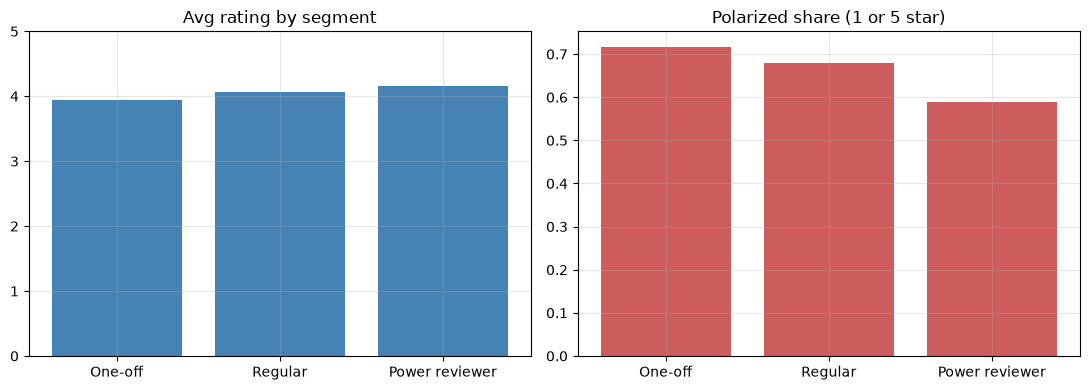

In [5]:
order = ["One-off", "Regular", "Power reviewer"]
d = q1.set_index("reviewer_segment").reindex(order)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(order, d["avg_rating"], color="steelblue"); ax[0].set_title("Avg rating by segment"); ax[0].set_ylim(0, 5)
ax[1].bar(order, d["polarized_share"], color="indianred"); ax[1].set_title("Polarized share (1 or 5 star)")
plt.tight_layout(); plt.show()

**ตอบ** — เทียบ `polarized_share` ของ One-off กับ Regular/Power: ถ้า One-off สูงกว่า = คนรีวิวครั้งเดียว
ให้คะแนนสุดขั้วกว่าจริง คะแนนรวมของทั้งชุดจึงถูกดึงด้วยความเห็นแบบรัก-เกลียด

**ใช้ต่อ** — เวลารายงานคะแนนเฉลี่ย ควรกำกับว่ามาจากฐานผู้รีวิวแบบไหน และถ้าจะกรองรีวิวน่าสงสัย
(→ B5) One-off + not verified คือกลุ่มเริ่มต้นที่ควรเพ่ง

---
# Q2 — สินค้าไหน "ระเบิดเวลา": รีวิวเยอะแต่คะแนนต่ำ?
*(เดิม Q6)*

**ทำไมสำคัญ** — ปัญหาที่กระทบคน *จำนวนมาก* สำคัญกว่าสินค้าคะแนนต่ำที่มีคนซื้อไม่กี่คน
การจัดลำดับด้วย "จำนวนรีวิว × คะแนนต่ำ" ชี้ว่าควรแก้ตัวไหนก่อน

**ข้อมูล** — `fact_review` group by product, `HAVING` กันสินค้ารีวิวน้อย + join `dim_product` เอาชื่อ/แบรนด์

In [6]:
q2 = con.sql("""
    WITH per_product AS (
        SELECT product_key,
               count(*)                       AS n_reviews,
               round(avg(rating), 2)          AS avg_rating,
               round(avg(is_negative::INT),3) AS negative_share
        FROM fact_review
        GROUP BY product_key
        HAVING count(*) >= 100          -- ต้องมีรีวิวพอให้คะแนนนิ่ง
    )
    SELECT p.category, p.store AS brand, p.product_title,
           pp.n_reviews, pp.avg_rating, pp.negative_share
    FROM per_product pp
    JOIN dim_product p USING (product_key)
    WHERE pp.avg_rating < 3           -- คะแนนต่ำ
    ORDER BY pp.n_reviews DESC          -- กระทบคนเยอะสุดก่อน
    LIMIT 20
""").df()
q2

,category,brand,product_title,n_reviews,avg_rating,negative_share
0,Health_and_Personal_Care,Nature's MACE,Nature's MACE Cat Repellent 1 Gallon Spray/Tre...,1527,2.74,0.511
1,All_Beauty,DASKY,DASKY 29W Digital Anti Static Ceramic Hair Str...,499,2.84,0.475
2,All_Beauty,BELLISSO,Purple Shampoo and Conditioner Set - Sulfate F...,474,2.90,0.479
3,Health_and_Personal_Care,Rosallini,Twist Holder Clip Magic Roll Bun Hair Twist Br...,473,2.66,0.531
4,Amazon_Fashion,JASSINS,Pooqdo New Women Bang Multilayer Pendant Chain...,453,2.73,0.488
5,Health_and_Personal_Care,EVEO,Glasses Cleaner - Eyeglass Cleaner - Lens Wipe...,451,2.90,0.490
6,All_Beauty,Tooletries,Tooletries – Oliver Shower Mirror - Premium Sh...,447,2.92,0.472
7,Amazon_Fashion,Jewel Town,New Custom Fit 14k Gold Plated Hip Hop Teeth G...,390,2.97,0.428
8,Amazon_Fashion,Yuren,Yuren 3 Pieces 925 Sterling Silver 2mm Snake C...,359,2.81,0.515
9,Amazon_Fashion,Yuren,Yuren Twist Ring for Women Fashion 925 sterlin...,337,2.17,0.694


**ตอบ** — ตารางนี้คือรายชื่อสินค้าที่ควรเฝ้าระวัง/แก้ก่อน เรียงตามจำนวนคนที่เจอปัญหา
(`n_reviews` มาก + `avg_rating < 3`)

**ระวัง** — `product_title` ใน dataset #1 ยังเป็นข้อความดิบ (มี `<b>`, `&amp;` ปน)
ถ้าต้องการชื่อสะอาดใช้ `product_features.parquet` จาก dataset #2

**ใช้ต่อ** — ส่งรายชื่อนี้ให้ทีมจัดซื้อ/คุณภาพ ตรวจว่าเป็นปัญหาสินค้าเอง หรือคำบรรยาย/ความคาดหวังไม่ตรง

---
# Q3 — ราคาหาย 79% บิดผลการวิเคราะห์แค่ไหน?
*(เดิม Q9)*

**ทำไมสำคัญ** — ถ้าจะวิเคราะห์ราคา (Q8/A2) เราต้องกรองสินค้าที่ไม่รู้ราคาทิ้ง
แต่ถ้าการหายของราคา **ไม่สุ่ม** การกรองจะทำให้ผล *เอียง* ไม่ใช่แค่ตัวอย่างเล็กลง

**ข้อมูล** — เทียบคะแนนรีวิวของสินค้า *รู้ราคา* vs *ไม่รู้ราคา*

In [7]:
q3 = con.sql("""
    SELECT
        CASE WHEN p.price IS NULL THEN 'ไม่รู้ราคา (unknown)' ELSE 'รู้ราคา (known)' END AS price_known,
        count(*)                             AS n_reviews,
        round(100.0*count(*)/sum(count(*)) OVER (), 1) AS pct_of_reviews,
        round(avg(f.rating), 2)              AS avg_rating,
        round(avg(f.is_negative::INT), 3)    AS negative_share
    FROM fact_review f
    JOIN dim_product p USING (product_key)
    GROUP BY 1 ORDER BY avg_rating
""").df()
q3

,price_known,n_reviews,pct_of_reviews,avg_rating,negative_share
0,ไม่รู้ราคา (unknown),2878650,78.7,3.92,0.204
1,รู้ราคา (known),780286,21.3,4.15,0.160


**ตอบ** — สินค้า *ไม่รู้ราคา* ได้คะแนนเฉลี่ยต่ำกว่า *รู้ราคา* อย่างเป็นระบบ
→ การหายของราคา **มีทิศทาง (biased)** ไม่ใช่สุ่ม

**ผลกระทบ** — เวลาทำ A2 (กรอง `price_band = 'Unknown'` ทิ้ง) กลุ่มที่เหลือคือกลุ่มที่คะแนน *ดีกว่าค่าจริง*
→ ข้อสรุปเรื่องราคาจะ **เอนไปทางบวก** ต้องรายงานทุกครั้งว่ากรองไป ~79% และห้ามเอาไปอ้างกับสินค้าทั้งหมด

---
# Q4 — รีวิวมีรูปมีประโยชน์กว่าจริงไหม คุ้มที่จะดันไหม?
*(เดิม Q11)*

**ทำไมสำคัญ** — รีวิวมีรูปมีน้อยมาก (~6%) ถ้าพิสูจน์ได้ว่ามันช่วยคนอื่นตัดสินใจ (helpful) จริง
ก็คุ้มที่จะออกแบบ UX ให้แนบรูปง่ายขึ้น

**ข้อมูล** — `has_images` × `helpful_vote` (ดู median คู่ avg เพราะแจกแจงเบ้ขวา)

In [8]:
q4 = con.sql("""
    SELECT
        f.category,
        f.has_images,
        count(*)                                 AS n_reviews,
        round(avg(f.helpful_vote), 2)            AS avg_helpful,
        median(f.helpful_vote)                   AS median_helpful,
        round(avg((f.helpful_vote > 0)::INT), 3) AS share_any_vote  -- มีคนโหวตอย่างน้อย 1
    FROM fact_review f
    GROUP BY f.category, f.has_images
    ORDER BY f.category, f.has_images
""").df()
q4

,category,has_images,n_reviews,avg_helpful,median_helpful,share_any_vote
0,All_Beauty,False,635269,0.77,0.0,0.251
1,All_Beauty,True,58983,2.56,0.0,0.444
2,Amazon_Fashion,False,2317176,0.42,0.0,0.180
3,Amazon_Fashion,True,158518,2.75,0.0,0.459
4,Health_and_Personal_Care,False,467940,1.06,0.0,0.275
5,Health_and_Personal_Care,True,21050,2.70,0.0,0.437


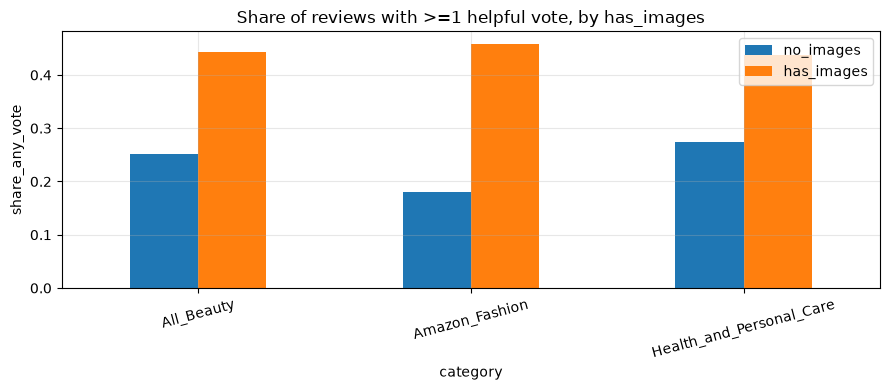

In [9]:
piv = q4.pivot(index="category", columns="has_images", values="share_any_vote")
piv.columns = ["no_images", "has_images"]
piv.plot(kind="bar", figsize=(9, 4))
plt.title("Share of reviews with >=1 helpful vote, by has_images")
plt.ylabel("share_any_vote"); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

**ตอบ** — ถ้าแถว `has_images = true` มี `avg_helpful` และ `share_any_vote` สูงกว่า `false` ทุกหมวด
= รีวิวมีรูปมีประโยชน์กว่าจริง คุ้มที่จะดัน

**ระวัง** — `avg_helpful` สูงแต่ `median_helpful` มักเป็น 0 (แจกแจงเบ้ขวา ส่วนใหญ่ 0 โหวต)
จึงดู `share_any_vote` เป็นตัวหลักดีกว่า และ `helpful_vote` ยังมีอคติเรื่องอายุรีวิว (เก่ากว่าสะสมโหวตนานกว่า)

**ใช้ต่อ** — ถ้าคุ้ม → ทำปุ่มแนบรูปให้เด่นขึ้น / กระตุ้นด้วย incentive

---
# Q5 — ลูกค้าบ่นเรื่องอะไรในรีวิวเชิงลบ?
*(เดิม Q14)*

**หมายเหตุวิธีทำ** — คำถามนี้ "เต็มรูปแบบ" ต้องใช้ **topic modeling** (B4) ซึ่งเป็นโมเดล
แต่ทำเวอร์ชัน *analytics ล้วน* ได้ด้วยการ **นับคำบ่นที่พบบ่อย** ในข้อความรีวิว 1–2 ดาว ด้วย SQL `LIKE`
→ ได้ภาพคร่าว ๆ ว่าแต่ละหมวดบ่นเรื่องอะไรต่างกัน โดยไม่ต้องเทรนโมเดล

**ข้อมูล** — `review_text` join `fact_review` (`is_negative = true`)

In [10]:
# นับสัดส่วนรีวิวเชิงลบที่มีคำบ่นแต่ละกลุ่ม แยกตามหมวด (lower ก่อนเทียบ)
q5 = con.sql("""
    WITH neg AS (
        SELECT f.category, lower(t.review_text) AS txt
        FROM fact_review f
        JOIN review_text t USING (review_id)
        WHERE f.is_negative
    )
    SELECT
        category,
        count(*)                                                          AS n_negative,
        round(avg((txt LIKE '%size%'  OR txt LIKE '%fit%'   OR txt LIKE '%small%' OR txt LIKE '%large%')::INT),3) AS size_fit,
        round(avg((txt LIKE '%cheap%' OR txt LIKE '%broke%' OR txt LIKE '%quality%')::INT),3)                     AS quality,
        round(avg((txt LIKE '%fake%'  OR txt LIKE '%counterfeit%' OR txt LIKE '%not real%')::INT),3)              AS fake,
        round(avg((txt LIKE '%smell%' OR txt LIKE '%scent%'  OR txt LIKE '%odor%')::INT),3)                       AS smell,
        round(avg((txt LIKE '%refund%'OR txt LIKE '%return%' OR txt LIKE '%money back%')::INT),3)                 AS refund_return,
        round(avg((txt LIKE '%ship%'  OR txt LIKE '%deliver%'OR txt LIKE '%arrived%'  OR txt LIKE '%package%')::INT),3) AS shipping
    FROM neg
    GROUP BY category ORDER BY n_negative DESC
""").df()
q5

,category,n_negative,size_fit,quality,fake,smell,refund_return,shipping
0,Amazon_Fashion,471720,0.355,0.246,0.009,0.013,0.132,0.055
1,All_Beauty,143489,0.093,0.141,0.015,0.078,0.088,0.055
2,Health_and_Personal_Care,97401,0.125,0.125,0.009,0.055,0.105,0.055


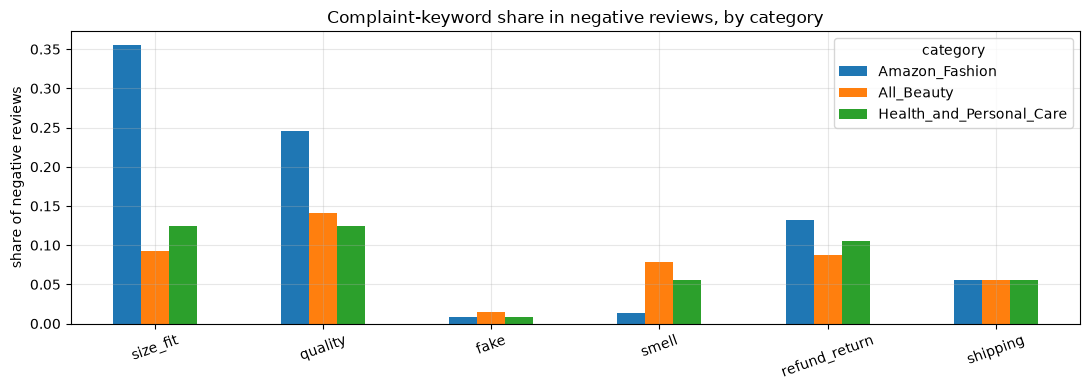

In [11]:
topics = ["size_fit", "quality", "fake", "smell", "refund_return", "shipping"]
q5.set_index("category")[topics].T.plot(kind="bar", figsize=(11, 4))
plt.title("Complaint-keyword share in negative reviews, by category")
plt.ylabel("share of negative reviews"); plt.xticks(rotation=20)
plt.legend(title="category"); plt.tight_layout(); plt.show()

**ตอบ** — เทียบสัดส่วนคำบ่นข้ามหมวด:
- คาดว่า `Amazon_Fashion` เด่นเรื่อง **size_fit** (ไซซ์/ความพอดี)
- `All_Beauty` / `Health` เด่นเรื่อง **smell / fake / quality** (กลิ่น/ของปลอม/คุณภาพ)

**ข้อจำกัดของวิธีนี้** — `LIKE` นับ *การมีคำ* ไม่เข้าใจบริบท (เช่น "great quality" ก็ติด `quality`)
เป็นแค่ภาพคร่าว ๆ ถ้าต้องการหัวข้อที่แม่นจริงต้องทำ topic modeling (B4) ใน `model/`

**ใช้ต่อ** — ส่งหมวดคำบ่นที่พบบ่อยให้ทีมพัฒนาสินค้า/ทีมเขียนรายละเอียดสินค้าแก้ตรงจุด

---
# สรุป

| # | คำถาม | คำตอบสั้น | ใช้ทำอะไรต่อ |
|---|---|---|---|
| Q1 | One-off vs ขาประจำ | ดู `polarized_share` ต่าง = คะแนนรวมถูกครอบงำโดยความเห็นสุดขั้ว | กำกับฐานผู้รีวิวเวลารายงานคะแนน |
| Q2 | สินค้าระเบิดเวลา | ตารางสินค้ารีวิวเยอะ+คะแนนต่ำ เรียงตามคนที่โดน | ส่งทีมจัดซื้อ/คุณภาพแก้ก่อน |
| Q3 | ราคาหาย 79% | ไม่รู้ราคา คะแนนต่ำกว่า = missing มีทิศทาง | กำกับ A2 ว่าเอนบวก |
| Q4 | รีวิวมีรูป | รูป → helpful สูงกว่า (ดู share_any_vote) | ดัน UX แนบรูป |
| Q5 | บ่นเรื่องอะไร | นับคำบ่นข้ามหมวด (คร่าว ๆ) | ส่งทีมสินค้า; ทำจริงใช้ B4 |

**ข้อจำกัดที่ต้องกำกับทุกข้อ** — รีวิว 2022+ เก็บไม่ครบ · ราคาหาย 79% แบบไม่สุ่ม ·
จำนวนรีวิว ≠ ยอดขาย · selection bias · `dim_user` คิดจาก 3 หมวดนี้เท่านั้น

In [12]:
# con.close()  # ปิด connection เมื่อเลิกใช้